In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [17]:
def build_backbone(input_shape=(224,224,3)):
  inputs=keras.Input(shape=input_shape)
  x=keras.layers.Conv2D(64,(3,3),activation='relu',padding='same')(inputs)
  x=keras.layers.MaxPooling2D((2,2))(x)
  x=keras.layers.Conv2D(128,(3,3),activation='relu',padding='same')(x)
  x=keras.layers.MaxPooling2D((2,2))(x)
  x=keras.layers.Conv2D(256,(3,3),activation='relu',padding='same')(x)
  x=keras.layers.MaxPooling2D((2,2))(x)
  outputs=keras.layers.Conv2D(512,(3,3),activation='relu',padding='same')(x)
  return keras.Model(inputs,outputs)

backbone=build_backbone()

In [18]:
def build_rpn(feature_map):
  rpn_conv=keras.layers.Conv2D(512,(3,3),padding='same',activation='relu')(feature_map)
  rpn_class=keras.layers.Conv2D(9*2,(1,1),padding='same',activation='sigmoid')(rpn_conv)
  rpn_bbox=keras.layers.Conv2D(9*4,(1,1))(rpn_conv)
  return rpn_class,rpn_bbox

In [19]:
class ROIPoolingLayer(tf.keras.layers.Layer):
  def __init__(self,pool_size,**kwargs):
    super(ROIPoolingLayer,self).__init__(**kwargs)
    self.pool_size=pool_size
  def call(self,inputs):
    feature_map,rois=inputs
    rois=tf.reshape(rois,(-1,4))
    batch_indices=tf.zeros((tf.shape(rois)[0],),dtype=tf.int32)
    pooled_rois=tf.image.crop_and_resize(feature_map,boxes=rois,box_indices=batch_indices,crop_size=self.pool_size)
    return pooled_rois
  def compute_output_shape(self,input_shape):
    feature_map_shape,rois_shape=input_shape
    num_rois=rois_shape[0]
    return (num_rois,self.pool_size[0],self.pool_size[1],feature_map_shape[-1])
roi_pooling_layer=ROIPoolingLayer((7,7))

In [20]:
def build_heads(pooled_rois,num_classes):
  flatten=keras.layers.Flatten()(pooled_rois)
  dense=keras.layers.Dense(1024,activation='relu')(flatten)
  classifier=keras.layers.Dense(num_classes,activation='softmax')(dense)
  bbox_regressor=keras.layers.Dense(num_classes*4)(dense)
  return classifier,bbox_regressor

In [21]:
def build_faster_rcnn(num_classes,input_shape=(224,224,3)):
  input_image=keras.Input(shape=input_shape)
  rois=keras.Input(shape=(None,4))
  backbone=build_backbone(input_shape)
  feature_map=backbone(input_image)
  rpn_class,rpn_bbox=build_rpn(feature_map)

  pooled_rois=roi_pooling_layer([feature_map,rois])
  classifier,bbox_regressor=build_heads(pooled_rois,num_classes)

  model=keras.Model(inputs=[input_image,rois],outputs=[rpn_class,rpn_bbox,classifier,bbox_regressor])
  return model

In [22]:
num_classes=80
faster_rcnn=build_faster_rcnn(num_classes)
faster_rcnn.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_7        │ (None, 28, 28,    │  1,550,976 │ input_layer_9[0]… │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer_1 │ (None, 7, 7, 512) │          0 │ functional_7[0][… │
│ (ROIPoolingLayer)   │                   │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 25088)     │          0 │ roi_pooling_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 28, 28,    │  2,359,808 │ functional_7[0][… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │ 25,691,136 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 28, 28,    │      9,234 │ conv2d_34[0][0]   │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 28, 28,    │     18,468 │ conv2d_34[0][0]   │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 80)        │     82,000 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 320)       │    328,000 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,039,622 (114.59 MB)

 Trainable params: 30,039,622 (114.59 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
def calculate_iou(box1,box2):
  ymin1,xmin1,ymax1,xmax1=box1
  ymin2,xmin2,ymax2,xmax2=box2
  intersection_ymin=max(ymin1,ymin2)
  intersection_xmin=max(xmin1,xmin2)
  intersection_ymax=min(ymax1,ymax2)
  intersection_xmax=min(xmax1,xmax2)
  intersection_area=max(intersection_ymax-intersection_ymin,0)*max(intersection_xmax-intersection_xmin,0)

  area1=(ymax1-ymin1)*(xmax1-xmin1)
  area2=(ymax2-ymin2)*(xmax2-xmin2)
  union_area=area1+area2-intersection_area
  iou=intersection_area/union_area
  return iou

In [24]:
# calculating precision recall
def calculate_precision_recall(pred_boxes,pred_scores,pred_labels,gt_boxes,gt_labels,iou_threshold=0.5):
  tp,fp=0,0
  matched_gt=set()

  for i,pred_box in enumerate(pred_boxes):
    if pred_scores[i]<iou_threshold:
      continue
    best_iou=0
    best_gt_idx=-1
    for j,gt_box in enumerate(gt_boxes):
      if pred_labels[i]==gt_labels[j] and j not in matched_gt:
        iou=calculate_iou(pred_box,gt_box)
        if iou>best_iou:
          best_iou=iou
          best_gt_idx=j
    if best_iou>=iou_threshold:
      tp+=1
      matched_gt.add(best_gt_idx)

    else:
      fp+=1
  fn=len(gt_boxes)-len(matched_gt)
  precision=tp/(tp+fp) if (tp+fp)>0 else 0
  recall  =tp/(tp+fn) if (tp+fn)>0 else 0
  return precision,recall

In [25]:
# Step 8: Calculate Average Precision (AP)
def calculate_ap(precisions, recalls):
    precisions = [0.0] + precisions + [0.0]
    recalls = [0.0] + recalls + [1.0]
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i - 1] = max(precisions[i - 1], precisions[i])
    indices = [i for i in range(1, len(recalls)) if recalls[i] != recalls[i - 1]]
    ap = sum((recalls[i] - recalls[i - 1]) * precisions[i] for i in indices)
    return ap

# Step 9: Calculate Mean Average Precision (mAP) Across All Classes
def calculate_map(predictions, ground_truths, num_classes, iou_threshold=0.5):
    average_precisions = []
    for class_id in range(1, num_classes):  # Assuming class_id 0 is background
        all_precisions = []
        all_recalls = []
        for pred, gt in zip(predictions, ground_truths):
            pred_boxes = [box for i, box in enumerate(pred['boxes']) if pred['labels'][i] == class_id]
            pred_scores = [score for i, score in enumerate(pred['scores']) if pred['labels'][i] == class_id]
            gt_boxes = [box for i, box in enumerate(gt['boxes']) if gt['labels'][i] == class_id]
            precision, recall = calculate_precision_recall(
                pred_boxes, pred_scores, [class_id] * len(pred_boxes), gt_boxes, [class_id] * len(gt_boxes), iou_threshold
            )
            all_precisions.append(precision)
            all_recalls.append(recall)
        ap = calculate_ap(all_precisions, all_recalls)
        average_precisions.append(ap)
    mAP = np.mean(average_precisions)
    return mAP


In [26]:
# Placeholder predictions and ground truths for testing
predictions = [
    {'boxes': [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8]], 'scores': [0.9, 0.7], 'labels': [1, 2]}
]

ground_truths = [
    {'boxes': [[0.12, 0.12, 0.42, 0.42], [0.5, 0.5, 0.8, 0.8]], 'labels': [1, 2]}
]

# Number of classes in the dataset (e.g., 80 for COCO)
num_classes = 80

# Calculate mAP
mean_ap = calculate_map(predictions, ground_truths, num_classes)
print(f"Mean Average Precision (mAP): {mean_ap:.4f}")


Mean Average Precision (mAP): 0.0253


In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as ops
import numpy as np

# =========================
# 1. Backbone
# =========================
class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = F.relu(self.conv4(x))
        return x


# =========================
# 2. RPN
# =========================
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()

        self.conv = nn.Conv2d(in_channels, 512, 3, padding=1)
        self.cls_layer = nn.Conv2d(512, num_anchors * 2, 1)
        self.reg_layer = nn.Conv2d(512, num_anchors * 4, 1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        rpn_class = torch.sigmoid(self.cls_layer(x))
        rpn_bbox = self.reg_layer(x)
        return rpn_class, rpn_bbox


# =========================
# 3. ROI Pooling (Torchvision)
# =========================
class ROIPool(nn.Module):
    def __init__(self, output_size=(7, 7)):
        super().__init__()
        self.pool = ops.RoIAlign(output_size, spatial_scale=1.0, sampling_ratio=-1)

    def forward(self, feature_map, rois):
        # rois format: [num_rois, 5] -> (batch_idx, x1, y1, x2, y2)
        return self.pool(feature_map, rois)


# =========================
# 4. Heads
# =========================
class Heads(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(in_features, 1024)
        self.cls = nn.Linear(1024, num_classes)
        self.reg = nn.Linear(1024, num_classes * 4)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        classifier = F.softmax(self.cls(x), dim=1)
        bbox_regressor = self.reg(x)

        return classifier, bbox_regressor


# =========================
# 5. Faster R-CNN Model
# =========================
class FasterRCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = Backbone()
        self.rpn = RPN()
        self.roi_pool = ROIPool((7, 7))

        self.heads = Heads(512 * 7 * 7, num_classes)

    def forward(self, images, rois):
        feature_map = self.backbone(images)

        rpn_class, rpn_bbox = self.rpn(feature_map)

        pooled_rois = self.roi_pool(feature_map, rois)

        classifier, bbox_regressor = self.heads(pooled_rois)

        return rpn_class, rpn_bbox, classifier, bbox_regressor


# =========================
# 6. Model Test
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FasterRCNN(num_classes=80).to(device)

# Dummy input
images = torch.randn(1, 3, 224, 224).to(device)

# Dummy ROIs: (batch_idx, x1, y1, x2, y2)
rois = torch.tensor([
    [0, 10, 10, 100, 100],
    [0, 50, 50, 150, 150]
], dtype=torch.float32).to(device)

outputs = model(images, rois)



Model ran successfully ✅


Uploading random image

In [35]:
from PIL import Image
import torchvision.transforms as T

# Get filename
img_path = '/content/TrainSorghumWeed (202).JPG'

# Load image
image = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

img_tensor = transform(image).unsqueeze(0)  # shape: [1, 3, 224, 224]

In [36]:
# dummy rois
rois = torch.tensor([
    [0, 30, 30, 180, 180]
], dtype=torch.float32)

In [38]:
model.eval()

with torch.no_grad():
    rpn_class, rpn_bbox, classifier, bbox = model(img_tensor, rois)

In [40]:
probs = classifier.squeeze().cpu().numpy()

pred_label = probs.argmax()
confidence = probs.max()

# print("Class probabilities:", probs)
# print("Predicted class:", pred_label)
# print("Confidence:", confidence)

# print("BBox output:", bbox)

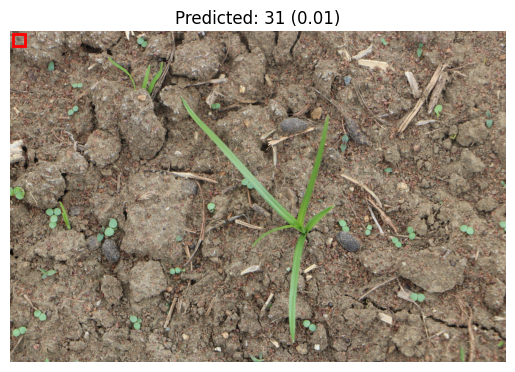

In [41]:
import matplotlib.pyplot as plt

plt.imshow(image)
x1, y1, x2, y2 = rois[0][1:].numpy()

# Draw rectangle
import matplotlib.patches as patches
ax = plt.gca()
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                         linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.title(f"Predicted: {pred_label} ({confidence:.2f})")
plt.axis("off")
plt.show()

Changing no of layers by adding 2 more convolution layers

In [46]:

# =========================
# 1. Backbone
# =========================
class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.conv5 = nn.Conv2d(512, 1024, 3, padding=1)
        self.pool5 = nn.MaxPool2d(2, 2)
        self.conv6 = nn.Conv2d(1024, 512, 3, padding=1) # Renamed from conv5 to conv6

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = F.relu(self.conv4(x))
        x = self.pool4(x)
        x = F.relu(self.conv5(x))
        x = self.pool5(x)
        x = F.relu(self.conv6(x)) # Corrected call
        return x


# =========================
# 2. RPN
# =========================
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()

        self.conv = nn.Conv2d(in_channels, 512, 3, padding=1)
        self.cls_layer = nn.Conv2d(512, num_anchors * 2, 1)
        self.reg_layer = nn.Conv2d(512, num_anchors * 4, 1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        rpn_class = torch.sigmoid(self.cls_layer(x))
        rpn_bbox = self.reg_layer(x)
        return rpn_class, rpn_bbox


# =========================
# 3. ROI Pooling (Torchvision)
# =========================
class ROIPool(nn.Module):
    def __init__(self, output_size=(7, 7)):
        super().__init__()
        self.pool = ops.RoIAlign(output_size, spatial_scale=1.0, sampling_ratio=-1)

    def forward(self, feature_map, rois):
        # rois format: [num_rois, 5] -> (batch_idx, x1, y1, x2, y2)
        return self.pool(feature_map, rois)


# =========================
# 4. Heads
# =========================
class Heads(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(in_features, 1024)
        self.cls = nn.Linear(1024, num_classes)
        self.reg = nn.Linear(1024, num_classes * 4)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        classifier = F.softmax(self.cls(x), dim=1)
        bbox_regressor = self.reg(x)

        return classifier, bbox_regressor


# =========================
# 5. Faster R-CNN Model
# =========================
class FasterRCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = Backbone()
        self.rpn = RPN()
        self.roi_pool = ROIPool((7, 7))

        self.heads = Heads(512 * 7 * 7, num_classes)

    def forward(self, images, rois):
        feature_map = self.backbone(images)

        rpn_class, rpn_bbox = self.rpn(feature_map)

        pooled_rois = self.roi_pool(feature_map, rois)

        classifier, bbox_regressor = self.heads(pooled_rois)

        return rpn_class, rpn_bbox, classifier, bbox_regressor


# =========================
# 6. Model Test
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = FasterRCNN(num_classes=80).to(device)


In [49]:
model2.eval()

with torch.no_grad():
    rpn_class, rpn_bbox, classifier, bbox = model2(img_tensor, rois)

In [52]:
probs = classifier.squeeze().cpu().numpy()

pred_label = probs.argmax()
confidence = probs.max()

pred_class = probs.argmax().item()

In [56]:
bbox = bbox.squeeze()  # shape: [num_classes * 4]

start = pred_class * 4
tx, ty, tw, th = bbox[start:start+4]

In [57]:
# cnvert roi to final box
roi = rois[0][1:]  # remove batch index

x1, y1, x2, y2 = roi

w = x2 - x1
h = y2 - y1
cx = x1 + 0.5 * w
cy = y1 + 0.5 * h

# Apply deltas
pred_cx = cx + tx * w
pred_cy = cy + ty * h
pred_w = w * torch.exp(tw)
pred_h = h * torch.exp(th)

# Convert back to corners
pred_x1 = pred_cx - 0.5 * pred_w
pred_y1 = pred_cy - 0.5 * pred_h
pred_x2 = pred_cx + 0.5 * pred_w
pred_y2 = pred_cy + 0.5 * pred_h

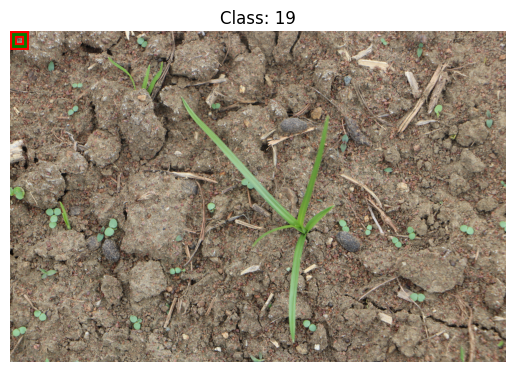

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.imshow(image)

ax = plt.gca()

# Original ROI (red)
roi_rect = patches.Rectangle(
    (x1, y1), w, h,
    linewidth=5, edgecolor='red', facecolor='none'
)
ax.add_patch(roi_rect)

# Predicted box (green)
pred_rect = patches.Rectangle(
    (pred_x1.item(), pred_y1.item()),
    (pred_x2 - pred_x1).item(),
    (pred_y2 - pred_y1).item(),
    linewidth=2, edgecolor='green', facecolor='none'
)
ax.add_patch(pred_rect)


plt.title(f"Class: {pred_class}")
plt.axis("off")
plt.show()

**Comment:**

Increasing the number of layers doesnt change much except the predicted class changes. The confidence score remains the same
